# TC Track Diagnostics - E3SM Hindcast (ne30pg2)

This notebook starts from the TempestExtremes outputs generated by `6a_run_tc_track_e3sm_hindcast.ipynb`.

It inspects stitched track files, builds lead-time track-density diagnostics, optionally adds IBTrACS observed diagnostics, and can save ENSO regression outputs.


In [2]:
import os
import sys
import subprocess
import xarray as xr
import matplotlib.pyplot as plt

# PROJ data path — auto-resolved when running under the e3sm_analysis kernel
# (CONDA_PREFIX is set).  Hardcoded fallback only needed if kernel is not activated.
_proj_path = os.path.join(os.environ.get("CONDA_PREFIX", ""), "share", "proj")
if not os.path.exists(_proj_path):
    _proj_path = "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/share/proj"
os.environ["PROJ_LIB"]  = _proj_path
os.environ["PROJ_DATA"] = _proj_path

import cartopy.crs as ccrs

# Python interpreter for the tracking script.
# When the kernel IS e3sm_analysis, sys.executable is already correct.
PYTHON = sys.executable
print(f"PYTHON      : {PYTHON}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set — fallback paths used)')}")


PYTHON      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/homes/z/zhan391/.conda/envs/e3sm_analysis


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error.

In [3]:
import numpy as np
from pathlib import Path

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #

# TempestExtremes track and histogram files generated by the runner notebook.
TRACK_DIR    = Path("/global/cfs/cdirs/e3sm/S2S2D/post_process")

# Diagnostics written by this notebook.
OUTDIR       = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE")

# Local helper modules used by this diagnostics notebook.
SCRIPTS_DIR  = Path("/global/homes/z/zhan391/code/ESP-Lab/scripts")

# Figures from this notebook are saved beside the notebook file.
NOTEBOOK_DIR = SCRIPTS_DIR.parent / "jupyter"

# ------------------------------------------------------------------ #
#  CASES
# ------------------------------------------------------------------ #

case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"

years  = 1980
yeare  = 2018
yexcl  = None          # set to a year int to exclude, or None

init_months = [5, 11]  # May and November starts

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]

CASES = [
    f"{case_prefix}_{year}{init_month:02d}0100"
    for init_month in init_months
    for year in lead_years
]

print(f"Total cases: {len(CASES)}")
print("First few:", CASES[:3])
print("Last few: ", CASES[-3:])

# ------------------------------------------------------------------ #
#  ENSEMBLE / PARSET
# ------------------------------------------------------------------ #

case_nens = 10
members   = [f"EN{i:02d}" for i in range(case_nens)]
MEMBERS   = members
NENS      = None   # e.g. 3 for a quick test
PARSET    = "set3"

# Replace existing diagnostics NetCDF files when rerunning with a new method/setup.
OVERWRITE_OUTPUT = True


Total cases: 78
First few: ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1981050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1982050100']
Last few:  ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2016110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2017110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100']


## Validate — run this before anything else

In [4]:
import subprocess, xarray as xr, matplotlib.pyplot as plt, cartopy.crs as ccrs

# ---- enforce all required fields are set ----
_required = {
    "CASES":        CASES,
    "TRACK_DIR":  TRACK_DIR,
    "OUTDIR":     OUTDIR,
    "SCRIPTS_DIR":  SCRIPTS_DIR,
    "MEMBERS":      MEMBERS,
    "PARSET":       PARSET,
    "OVERWRITE_OUTPUT": OVERWRITE_OUTPUT,
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise ValueError(
        "The following required fields are still None — fill them in the Configuration cell:\n"
        + "\n".join(f"  {k}" for k in _missing)
    )

# ---- check diagnostics inputs/outputs ----
_errors = []
if not TRACK_DIR.is_dir():
    _errors.append(f"TRACK_DIR does not exist: {TRACK_DIR}")
if not SCRIPTS_DIR.is_dir():
    _errors.append(f"SCRIPTS_DIR does not exist: {SCRIPTS_DIR}")

missing_case_dirs = [case for case in CASES if not (TRACK_DIR / case).is_dir()]
if missing_case_dirs:
    preview = ", ".join(missing_case_dirs[:5])
    more = "" if len(missing_case_dirs) <= 5 else f" ... ({len(missing_case_dirs) - 5} more)"
    _errors.append(f"Case directories not found under TRACK_DIR: {preview}{more}")

if _errors:
    raise FileNotFoundError("Path validation failed:\n" + "\n".join(_errors))

# ---- resolve member list from TRACK_DIR ----
_ref_case_dir = TRACK_DIR / CASES[0]
_all_members = sorted(
    p.name for p in _ref_case_dir.iterdir()
    if p.is_dir() and p.name.startswith("EN")
)
members_avail = list(MEMBERS) if MEMBERS else _all_members
if not members_avail:
    raise ValueError(f"No EN* member directories found in {_ref_case_dir}")
if NENS is not None:
    members_avail = members_avail[:NENS]

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Configuration valid ✓")
print(f"  Cases         : {len(CASES)} total  ({CASES[0]}  ...  {CASES[-1]})")
print(f"  TRACK_DIR    : {TRACK_DIR}")
print(f"  OUTDIR       : {OUTDIR}")
print(f"  SCRIPTS_DIR   : {SCRIPTS_DIR}")
print(f"  Members       : {members_avail}  (NENS={NENS})")
print(f"  Parset        : {PARSET}")
print(f"  Overwrite out : {OVERWRITE_OUTPUT}")
print(f"\n  Example input: {TRACK_DIR / CASES[0] / members_avail[0] / 'post' / 'atm' / 'tc-analysis'}")


Configuration valid ✓
  Cases         : 78 total  (WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100  ...  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100)
  TRACK_DIR    : /global/cfs/cdirs/e3sm/S2S2D/post_process
  OUTDIR       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE
  SCRIPTS_DIR   : /global/homes/z/zhan391/code/ESP-Lab/scripts
  Members       : ['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09']  (NENS=None)
  Parset        : set3
  Overwrite out : True

  Example input: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis


## Generated Track Outputs

Run this after the runner notebook has produced the `*_TCS_track.txt` and `*_TCS_hist.nc` files.


In [5]:
# List all track files produced across all cases
track_files = []
for case in CASES:
    track_files += sorted(
        (TRACK_DIR / case).glob(f"EN*/post/atm/tc-analysis/*_{PARSET}_TCS_track.txt")
    )

print(f"Track files found: {len(track_files)}  across {len(CASES)} cases")
for f in track_files[:20]:
    size_kb = f.stat().st_size / 1e3
    print(f"  {f.relative_to(TRACK_DIR)}  ({size_kb:.0f} kB)")
if len(track_files) > 20:
    print(f"  ... ({len(track_files) - 20} more)")


Track files found: 780  across 78 cases
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt  (145 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN01/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN01_set3_TCS_track.txt  (130 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN02/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN02_set3_TCS_track.txt  (161 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN03/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN03_set3_TCS_track.txt  (134 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN04/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN04_set3_TCS_track.txt  (137 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_J

In [6]:
# Summarise one track file (StitchNodes format)
if track_files:
    fpath = track_files[0]
    print(f"Inspecting: {fpath}")
    with open(fpath) as fh:
        raw = fh.readlines()
    n_storms = sum(1 for line in raw if line.strip().startswith("start"))
    n_points = sum(1 for line in raw if line.strip() and not line.strip().startswith(("start", "#")))
    print(f"  Storm tracks : {n_storms}")
    print(f"  Track points : {n_points}")
    if n_storms > 0:
        print(f"  Avg length   : {n_points / n_storms:.1f} steps/storm")
    print("\nFirst 20 lines:")
    for line in raw[:20]:
        print(" ", line.rstrip())
else:
    print("No track files found — run Section 5 first.")

Inspecting: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt
  Storm tracks : 87
  Track points : 1807
  Avg length   : 20.8 steps/storm

First 20 lines:
  start	35	1980	5	12	0
  	9486	138.749089	10.812292	1.006395e+05	5.595629e+00	1.042194e-02	1980	5	12	0
  	9604	138.748888	11.974293	1.002750e+05	9.334697e+00	-2.833747e-04	1980	5	12	6
  	9604	138.748888	11.974293	1.005149e+05	9.960303e+00	-2.833747e-04	1980	5	12	12
  	9601	137.248872	11.703239	1.002748e+05	8.621535e+00	-2.687000e-04	1980	5	12	18
  	9602	135.748645	12.542275	1.003873e+05	1.154267e+01	2.013818e-06	1980	5	13	0
  	9602	135.748645	12.542275	1.001188e+05	9.709673e+00	2.013818e-06	1980	5	13	6
  	6119	134.251355	12.542275	1.002944e+05	9.696574e+00	-4.309142e-06	1980	5	13	12
  	6119	134.251355	12.542275	9.998031e+04	1.131913e+01	-4.309142e-06	1980	5	13	18
  	6118	1

Histogram files found: 780  across 78 cases
Plotting 'density': total=1422318, max=3887, nonzero cells=14620


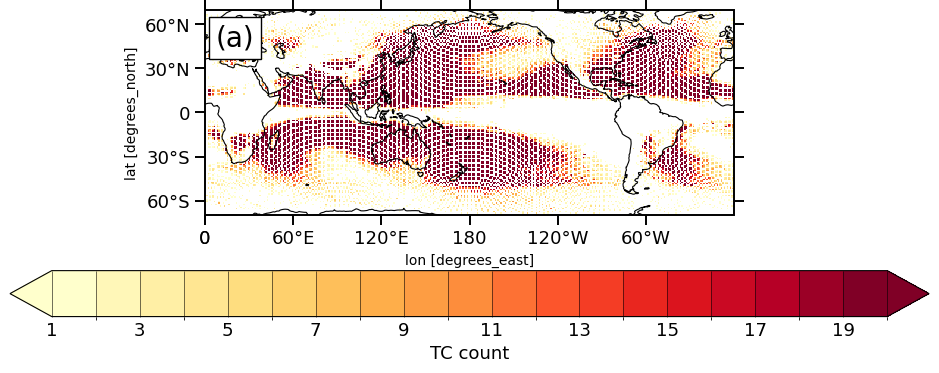

In [7]:
# Plot TC genesis density from HistogramNodes output (all cases)
hist_files = []
for case in CASES:
    hist_files += sorted(
        (TRACK_DIR / case).glob(f"EN*/post/atm/tc-analysis/*_{PARSET}_TCS_hist.nc")
    )

print(f"Histogram files found: {len(hist_files)}  across {len(CASES)} cases")

if hist_files:
    ds_hist = xr.open_mfdataset(
        hist_files,
        combine="nested",
        concat_dim="hist_file",
        coords="minimal",
        compat="override",
        combine_attrs="override",
    )
    varname = "density" if "density" in ds_hist.data_vars else list(ds_hist.data_vars)[0]
    density = ds_hist[varname].sum(
        dim=[d for d in ds_hist[varname].dims if d not in ("lat", "lon")]
    ).load()
    plot_density = density.where(density > 0)
    print(
        f"Plotting {varname!r}: total={float(density.sum()):.0f}, "
        f"max={float(density.max()):.0f}, nonzero cells={int((density > 0).sum())}"
    )
    levels = np.arange(1, 21, 1)
    cmap = plt.get_cmap("YlOrRd", len(levels) - 1).copy()
    # Cartopy wraps global pcolormesh plots; masked cells must be transparent
    # so the wrap mask does not cover valid density values.
    cmap.set_bad((1, 1, 1, 0))

    fig, ax = plt.subplots(
        1, 1, figsize=(13.5, 4.8),
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    )
    ax.set_extent([0, 360, -70, 70], crs=ccrs.PlateCarree())
    ax.set_title("E3SM", fontsize=24, fontweight="bold", pad=14)

    xticks = np.arange(0, 361, 60)
    xtick_labels = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(xtick_labels, fontsize=13)
    ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
    ax.set_yticklabels(["60°S", "30°S", "0", "30°N", "60°N"], fontsize=13)
    ax.tick_params(axis="both", which="major", direction="out", length=7, width=1.4,
                   top=True, right=True, labeltop=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    im = plot_density.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        extend="both",
        add_colorbar=False,
    )
    ax.coastlines(linewidth=0.8, color="black")
    ax.text(
        0.02, 0.86, "(a)", transform=ax.transAxes,
        fontsize=20, ha="left", va="center",
        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "square,pad=0.25"},
    )

    cbar = fig.colorbar(
        im, ax=ax, orientation="horizontal", pad=0.18, shrink=0.74,
        ticks=np.arange(1, 20, 2), drawedges=True,
    )
    cbar.set_label("TC count", fontsize=13)
    cbar.ax.tick_params(labelsize=13, length=0)
    fig.subplots_adjust(left=0.06, right=0.98, top=0.86, bottom=0.22)
    plt.show()
else:
    print("No histogram files found — run Section 5 first.")


## 7.  Lead-time diagnostic metrics

This block follows the same idea as the old SMYLE/NCL diagnostic workflow:

1. read stitched TempestExtremes track files,
2. attach each point to the hindcast initialization date,
3. assign points to target TC seasons and forecast lead months,
4. count unique TCs passing through each 5-degree global grid box,
5. integrate those 5-degree densities over broad TC basins,
6. save final lead-time track-density diagnostics as NetCDF.

The output has dimensions `season × lead × year × lat × lon`, with separate raw counts and case-member mean density fields.  It also stores basin masks and basin-integrated summaries for NH JJASON and SH DJFMAM basin-scale statistics.


In [8]:
import re
import pandas as pd

LEADS = np.array([1, 4, 7, 10, 13, 16, 19], dtype=int)

# Diagnostic track-density grid and definition.
DIAG_GRID_SIZE = 5.0

# Use "box" to reproduce the original S2D/SMYLE 5-degree grid-box workflow.
# Use "radius" only as a separate smooth unique-track diagnostic.
TRACK_DENSITY_METHOD = "box"  # "box" reproduces Yeager et al.; "radius" is a separate sensitivity diagnostic
TRACK_DENSITY_RADIUS_KM = 350.0  # used only when TRACK_DENSITY_METHOD == "radius"
TRACK_DENSITY_EARTH_RADIUS_KM = 6370.0

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from tc_track_density import TrackDensityConfig, compute_track_density

track_density_config = TrackDensityConfig(
    method=TRACK_DENSITY_METHOD,
    box_grid_size=DIAG_GRID_SIZE,
    radius_km=TRACK_DENSITY_RADIUS_KM,
    radius_dlat=DIAG_GRID_SIZE,
    radius_dlon=DIAG_GRID_SIZE,
    earth_radius_km=TRACK_DENSITY_EARTH_RADIUS_KM,
)

TRACK_DENSITY_DEFINITION = (
    f"Track points inside each {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° grid box, "
    "matching the original S2D/SMYLE workflow."
    if TRACK_DENSITY_METHOD == "box"
    else f"Unique storm tracks passing within {TRACK_DENSITY_RADIUS_KM:g} km of each grid point."
)
TRACK_DENSITY_UNITS = (
    "TC track points"
    if TRACK_DENSITY_METHOD == "box"
    else "TC storm passages"
)
# Backward-compatible alias for older plotting/metadata cells.
TRACK_DENSITY_MODE = TRACK_DENSITY_METHOD

# Model tracks are already TC-filtered by the TempestExtremes tracking stage.
# Keep this as None by default to avoid double-filtering model tracks.
POINT_WIND_MIN = None  # m/s; set only for sensitivity tests

# Yeager et al. NCL track_density output is allocated as 37 × 72 for
# gridsize=5.0, corresponding to lat=-90,-85,...,90 and lon=0,5,...,355.
# Keep radius mode on cell centers because it represents grid-point searches.
if TRACK_DENSITY_METHOD == "box":
    lat_diag = np.arange(-90.0, 90.0 + DIAG_GRID_SIZE / 2, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0, 360.0, DIAG_GRID_SIZE)
else:
    lat_diag = np.arange(-90.0 + DIAG_GRID_SIZE / 2, 90.0, DIAG_GRID_SIZE)
    lon_diag = np.arange(0.0 + DIAG_GRID_SIZE / 2, 360.0, DIAG_GRID_SIZE)
season_names = ["NH_JJASON", "SH_DJFMAM"]


def parse_case_init_time(case: str) -> pd.Timestamp:
    """Extract YYYYMMDDHH initialization tag from the case name."""
    match = re.search(r"_(\d{10})$", case)
    if match is None:
        raise ValueError(f"Could not find YYYYMMDDHH init tag at end of case name: {case}")
    tag = match.group(1)
    return pd.Timestamp(
        year=int(tag[:4]), month=int(tag[4:6]),
        day=int(tag[6:8]), hour=int(tag[8:10]),
    )


def parse_track_file(path: Path, case: str, member: str) -> pd.DataFrame:
    """
    Parse one StitchNodes track file.

    Track rows are expected to be:
      i lon lat slp wind zs year month day hour
    """
    rows = []
    storm_id = -1
    init_time = parse_case_init_time(case)

    with open(path) as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            if s.startswith("start"):
                storm_id += 1
                continue

            parts = s.split()
            if len(parts) < 10:
                continue

            rows.append({
                "case": case,
                "member": member,
                "storm_id": storm_id,
                "node": int(float(parts[0])),
                "lon": float(parts[1]) % 360.0,
                "lat": float(parts[2]),
                "slp": float(parts[3]),
                "wind": float(parts[4]),
                "zs": float(parts[5]),
                "time": pd.Timestamp(
                    year=int(parts[6]), month=int(parts[7]),
                    day=int(parts[8]), hour=int(parts[9]),
                ),
                "init_time": init_time,
            })

    return pd.DataFrame(rows)


def discover_track_files() -> pd.DataFrame:
    """Return metadata for all available track files in TRACK_DIR/CASE/EN*/..."""
    records = []
    for case in CASES:
        for member in members_avail:
            path = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis" / f"{case}_{member}_{PARSET}_TCS_track.txt"
            if path.exists():
                records.append({
                    "case": case,
                    "member": member,
                    "path": path,
                    "init_time": parse_case_init_time(case),
                })
    return pd.DataFrame(records)


track_meta = discover_track_files()
print(f"Track files available for diagnostics: {len(track_meta)}")
if not track_meta.empty:
    print(track_meta.head())
else:
    print("No track files found. Run Section 5 first.")


Track files available for diagnostics: 780
                                                case member  \
0  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOS...   EN00   
1  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOS...   EN01   
2  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOS...   EN02   
3  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOS...   EN03   
4  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOS...   EN04   

                                                path  init_time  
0  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
1  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
2  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
3  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  
4  /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYC... 1980-05-01  


In [9]:
def add_season_lead_info(points: pd.DataFrame) -> pd.DataFrame:
    """Attach season, season_year, and forecast lead month to track points."""
    if points.empty:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    out = []

    nh = points[points["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["season_year"] = nh["time"].dt.year.astype(int)
        nh["season_start_year"] = nh["season_year"]
        nh["season_start_month"] = 6
        out.append(nh)

    sh = points[(points["time"].dt.month == 12) | (points["time"].dt.month <= 5)].copy()
    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["season_year"] = np.where(sh["time"].dt.month == 12, sh["time"].dt.year, sh["time"].dt.year - 1).astype(int)
        sh["season_start_year"] = sh["season_year"]
        sh["season_start_month"] = 12
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(points.columns) + ["season", "season_year", "lead"])

    diag = pd.concat(out, ignore_index=True)
    diag["lead"] = (
        (diag["season_start_year"] - diag["init_time"].dt.year) * 12
        + (diag["season_start_month"] - diag["init_time"].dt.month)
    ).astype(int)
    diag = diag[diag["lead"].isin(LEADS)]

    n_before_year_filter = len(diag)
    diag = diag[diag["season_year"].isin(lead_years)]
    n_dropped = n_before_year_filter - len(diag)
    if n_dropped:
        print(f"Dropped {n_dropped:,} track positions outside configured model years {years}-{yeare}.")
    return diag.drop(columns=["season_start_year", "season_start_month"])


def build_sample_count(track_meta: pd.DataFrame) -> xr.DataArray:
    """Count contributing case-member files for each season/lead/year bin."""
    sample_count = xr.DataArray(
        np.zeros((len(season_names), len(LEADS), len(lead_years)), dtype=np.int32),
        dims=("season", "lead", "year"),
        coords={"season": season_names, "lead": LEADS, "year": lead_years},
        name="sample_count",
    )

    for row in track_meta.itertuples(index=False):
        init_time = row.init_time
        for lead in LEADS:
            season_start = init_time + pd.DateOffset(months=int(lead))
            if season_start.month == 6 and season_start.year in lead_years:
                sample_count.loc["NH_JJASON", lead, season_start.year] += 1
            if season_start.month == 12 and season_start.year in lead_years:
                sample_count.loc["SH_DJFMAM", lead, season_start.year] += 1

    return sample_count


def add_tc_points_to_density(
    density: xr.DataArray,
    points: pd.DataFrame,
    *,
    sample_cols: list[str],
    dim_cols: dict[str, str],
    density_method: str = TRACK_DENSITY_METHOD,
) -> None:
    """Add module-computed TC track density for each diagnostic sample."""
    if points.empty:
        return

    grouped = points.groupby(sample_cols, sort=False)
    for sample_values, sample_points in grouped:
        if len(sample_cols) == 1:
            sample_values = (sample_values,)
        sample_lookup = dict(zip(sample_cols, sample_values))
        loc = {dim: sample_lookup[col] for dim, col in dim_cols.items()}

        field = compute_track_density(
            lat=sample_points["lat"].to_numpy(),
            lon=sample_points["lon"].to_numpy(),
            track_id=sample_points["storm_id"].to_numpy(),
            config=track_density_config,
            method=density_method,
            grid_lat=lat_diag,
            grid_lon=lon_diag,
        )

        density.loc[loc] += field.astype(np.float32)


all_points = []
for row in track_meta.itertuples(index=False):
    df = parse_track_file(row.path, row.case, row.member)
    if POINT_WIND_MIN is not None and not df.empty:
        df = df[df["wind"] >= POINT_WIND_MIN]
    if not df.empty:
        all_points.append(df)

tracks = pd.concat(all_points, ignore_index=True) if all_points else pd.DataFrame()
tracks_diag = add_season_lead_info(tracks)

raw_density = xr.DataArray(
    np.zeros((len(season_names), len(LEADS), len(lead_years), len(lat_diag), len(lon_diag)), dtype=np.float32),
    dims=("season", "lead", "year", "lat", "lon"),
    coords={"season": season_names, "lead": LEADS, "year": lead_years, "lat": lat_diag, "lon": lon_diag},
    name="tc_track_density_count",
    attrs={
        "description": "Raw TC track-density count computed by scripts/tc_track_density.py.",
        "density_definition": TRACK_DENSITY_DEFINITION,
        "track_density_method": TRACK_DENSITY_METHOD,
        "grid_size_degrees": DIAG_GRID_SIZE,
        "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
        "point_wind_min": "none" if POINT_WIND_MIN is None else POINT_WIND_MIN,
    },
)

if not tracks_diag.empty:
    add_tc_points_to_density(
        raw_density,
        tracks_diag,
        sample_cols=["case", "member", "season", "lead", "season_year"],
        dim_cols={"season": "season", "lead": "lead", "year": "season_year"},
        density_method=TRACK_DENSITY_METHOD,
    )

sample_count = build_sample_count(track_meta)
mean_density = raw_density / sample_count.where(sample_count > 0)
mean_density.name = "tc_track_density_mean"
mean_density.attrs.update({
    "description": (
        "TC track-density count divided by contributing case-member samples; "
        "zero-storm members are included in the denominator."
    ),
    "density_definition": TRACK_DENSITY_DEFINITION,
    "track_density_method": TRACK_DENSITY_METHOD,
    "units": f"{TRACK_DENSITY_UNITS} per case_member season",
})

raw_storm_count = xr.DataArray(
    np.zeros((len(season_names), len(LEADS), len(lead_years)), dtype=np.float32),
    dims=("season", "lead", "year"),
    coords={"season": season_names, "lead": LEADS, "year": lead_years},
    name="tc_storm_count",
    attrs={
        "description": "Raw count of unique detected storms by TC season, lead, and verification year; accumulated over case-member samples.",
        "storm_count_definition": "Each storm_id is counted once per case/member/season/lead/year sample.",
        "point_wind_min": "none" if POINT_WIND_MIN is None else POINT_WIND_MIN,
        "units": "storms",
    },
)

if not tracks_diag.empty:
    model_storms = tracks_diag.drop_duplicates(
        ["case", "member", "season", "lead", "season_year", "storm_id"]
    )
    model_storm_groups = (
        model_storms
        .groupby(["season", "lead", "season_year"])
        .size()
        .reset_index(name="n_storms")
    )
    for row in model_storm_groups.itertuples(index=False):
        raw_storm_count.loc[dict(season=row.season, lead=row.lead, year=row.season_year)] += float(row.n_storms)

mean_storm_count = raw_storm_count / sample_count.where(sample_count > 0)
mean_storm_count.name = "tc_storm_count_mean"
mean_storm_count.attrs.update({
    "description": "Detected storm count divided by contributing case-member samples; zero-storm members are included in the denominator.",
    "storm_count_definition": "Each storm_id is counted once per case/member/season/lead/year sample.",
    "units": "storms per case_member season",
})

def write_netcdf(ds: xr.Dataset, path: Path, *, overwrite: bool = OVERWRITE_OUTPUT) -> None:
    """Write a NetCDF file, replacing an existing file when requested."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        if not overwrite:
            raise FileExistsError(f"Output already exists and OVERWRITE_OUTPUT=False: {path}")
        path.unlink()
    ds.to_netcdf(path)


BASIN_DEFS = {
    # TC-community basin masks on the 0-360 degrees-east grid.
    # Based on IBTrACS/WMO basin longitudes where they are longitude-defined.
    # EP and NA are coastline-aware in IBTrACS; these are rectangular
    # longitude approximations for gridded diagnostics.
    "NWP": {"season": "NH_JJASON", "lon": (100, 180), "lat": (0, 40), "long_name": "Northwestern Pacific"},
    "NA":  {"season": "NH_JJASON", "lon": (260, 360), "lat": (0, 40), "long_name": "North Atlantic"},
    "EP":  {"season": "NH_JJASON", "lon": (180, 260), "lat": (0, 40), "long_name": "Eastern Pacific"},
    "NI":  {"season": "NH_JJASON", "lon": (30, 100),  "lat": (0, 40), "long_name": "North Indian Ocean"},
    "SI":  {"season": "SH_DJFMAM", "lon": (10, 135), "lat": (-40, 0), "long_name": "South Indian Ocean"},
    "SP":  {"season": "SH_DJFMAM", "lon": (135, 290), "lat": (-40, 0), "long_name": "South Pacific Ocean"},
}


def build_basin_mask() -> xr.DataArray:
    """Return season-aware basin masks on the diagnostic 5-degree grid."""
    mask = xr.DataArray(
        np.zeros((len(BASIN_DEFS), len(season_names), len(lat_diag), len(lon_diag)), dtype=np.int8),
        dims=("basin", "season", "lat", "lon"),
        coords={"basin": list(BASIN_DEFS), "season": season_names, "lat": lat_diag, "lon": lon_diag},
        name="basin_mask",
    )
    for basin, spec in BASIN_DEFS.items():
        lon0, lon1 = spec["lon"]
        lat0, lat1 = spec["lat"]
        in_lon = (mask.lon >= lon0) & (mask.lon < lon1)
        in_lat = (mask.lat >= lat0) & (mask.lat < lat1)
        mask.loc[dict(basin=basin, season=spec["season"], lat=in_lat, lon=in_lon)] = 1
    mask.attrs.update({
        "description": "Broad TC basin masks used for basin-scale statistics.",
        "basin_long_names": "; ".join(f"{k}={v['long_name']}" for k, v in BASIN_DEFS.items()),
    })
    return mask


basin_mask = build_basin_mask()
basin_count = (raw_density * basin_mask).sum(("lat", "lon"))
basin_count.name = "tc_basin_track_density_count"
basin_count.attrs.update({
    "description": "Basin-integrated sum of 5-degree TC track-density counts.",
    "units": TRACK_DENSITY_UNITS,
})
basin_mean = (mean_density * basin_mask).sum(("lat", "lon"))
basin_mean.name = "tc_basin_track_density_mean"
basin_mean.attrs.update({
    "description": "Basin-integrated sum of case-member-mean 5-degree TC track-density counts.",
    "units": f"{TRACK_DENSITY_UNITS} per case_member",
})

if not tracks.empty:
    tracks["lead_days"] = (tracks["time"] - tracks["init_time"]).dt.total_seconds() / 86400.0

DS_DIAG = xr.Dataset({
    "tc_track_density_count": raw_density,
    "tc_track_density_mean": mean_density,
    "tc_storm_count": raw_storm_count,
    "tc_storm_count_mean": mean_storm_count,
    "sample_count": sample_count,
    "basin_mask": basin_mask,
    "tc_basin_track_density_count": basin_count,
    "tc_basin_track_density_mean": basin_mean,
})
DS_DIAG.attrs.update({
    "source": "TempestExtremes StitchNodes tracks from run_tc_track_e3sm.py",
    "parset": PARSET,
    "case_prefix": case_prefix,
    "years": f"{years}-{yeare}",
    "init_months": ",".join(str(m) for m in init_months),
    "track_density_method": TRACK_DENSITY_METHOD,
    "track_density_definition": TRACK_DENSITY_DEFINITION,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
})

DIAG_OUT = OUTDIR / f"tc_lead_track_density_{case_prefix}_{PARSET}_{years}_{yeare}.nc"
write_netcdf(DS_DIAG, DIAG_OUT)

print(f"Track positions read       : {len(tracks):,}")
print(f"Diagnostic positions used : {len(tracks_diag):,}")
print(f"Track-density method    : {TRACK_DENSITY_METHOD}")
print(f"Diagnostic grid size    : {DIAG_GRID_SIZE:g}° × {DIAG_GRID_SIZE:g}°")
print(f"Saved diagnostics       : {DIAG_OUT}")
print(DS_DIAG)


Dropped 26,694 track positions outside configured model years 1980-2018.
Track positions read       : 1,422,318
Diagnostic positions used : 1,363,146
Track-density method    : box
Diagnostic grid size    : 5° × 5°
Saved diagnostics       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2018.nc
<xarray.Dataset> Size: 18MB
Dimensions:                       (season: 2, lead: 7, year: 39, lat: 37,
                                   lon: 72, basin: 6)
Coordinates:
  * season                        (season) <U9 72B 'NH_JJASON' 'SH_DJFMAM'
  * lead                          (lead) int64 56B 1 4 7 10 13 16 19
  * year                          (year) int64 312B 1980 1981 1982 ... 2017 2018
  * lat                           (lat) float64 296B -90.0 -85.0 ... 85.0 90.0
  * lon                           (lon) float64 576B 0.0 5.0 ... 350.0 355.0
  * basin                         (basin) <U3 72B 'NWP' 'NA' 'EP' 'NI' 'SI'

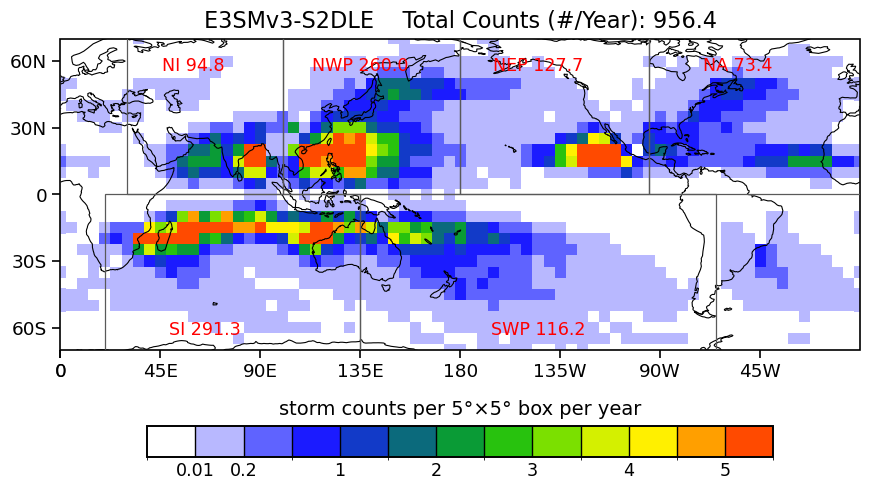

In [10]:
# Publication-style annual global TC track-density map.
# Annual global = NH JJASON + SH DJFMAM, then averaged over available years.

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# ============================================================
# User-controlled setup parameters
# ============================================================

# Data selection
PLOT_SEASONS = ["NH_JJASON", "SH_DJFMAM"]
PLOT_LEAD = None  # None = automatically use first available lead

# Map/domain setup
MAP_EXTENT = [0, 360, -70, 70]
CENTRAL_LONGITUDE = 180
FIGSIZE = (8.8, 5.1)

# Axis ticks and labels
XTICKS = np.arange(0, 361, 45)
XTICK_LABELS = ["0", "45E", "90E", "135E", "180", "135W", "90W", "45W", "0"]

YTICKS = [-60, -30, 0, 30, 60]
YTICK_LABELS = ["60S", "30S", "0", "30N", "60N"]

# Title and labels
MODEL_LABEL = "E3SMv3-S2DLE"
COLORBAR_LABEL = "storm counts per 5°×5° box per year"

# Font-size setup
FONTZ = 14  # base font size

TITLE_FONTSIZE = 1.15 * FONTZ
TICK_FONTSIZE = 0.95 * FONTZ
BASIN_LABEL_FONTSIZE = 0.90 * FONTZ
COLORBAR_TITLE_FONTSIZE = 1.00 * FONTZ
COLORBAR_TICK_FONTSIZE = 0.90 * FONTZ

# Colorbar setup
COLORBAR_BOUNDS = [
    0.0, 0.01, 0.2, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0
]

COLORBAR_TICKS = [0.01, 0.2, 1, 2, 3, 4, 5]
COLORBAR_TICK_LABELS = ["0.01", "0.2", "1", "2", "3", "4", "5"]

COLORBAR_COLORS = [
    "white",
    "#b8b8ff",
    "#5f63ff",
    "#1b1bff",
    "#123ac8",
    "#0b6a7c",
    "#0a9b36",
    "#28c20e",
    "#7be000",
    "#d4f000",
    "#fff000",
    "#ff9f00",
    "#ff4a00",
]

COLORBAR_FRACTION = 0.07
COLORBAR_PAD = 0.17

# Values below this threshold are hidden on the map
MIN_PLOT_VALUE = 0.01

# Basin boxes from Knutson et al. (2020, BAMS), using 0–360 longitude convention.
SHOW_BASIN_BOXES = True
INCLUDE_SOUTH_ATLANTIC_BASINS = False  # True = include optional SA1 and SA2 boxes

MAIN_BASINS = {
    "NA":  {"lon1": 265, "lon2": 360, "lat1": 0,   "lat2": 90, "text_xy": (305, 58)},
    "NEP": {"lon1": 180, "lon2": 265, "lat1": 0,   "lat2": 90, "text_xy": (215, 58)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 90, "text_xy": (135, 58)},
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 90, "text_xy": (60, 58)},
    "SI":  {"lon1": 20,  "lon2": 135, "lat1": -90, "lat2": 0,  "text_xy": (65, -61)},
    "SWP": {"lon1": 135, "lon2": 295, "lat1": -90, "lat2": 0,  "text_xy": (215, -61)},
}

OPTIONAL_BASINS = {
    "SA1": {"lon1": 295, "lon2": 360, "lat1": -90, "lat2": 0,  "text_xy": (325, -35)},
    "SA2": {"lon1": 0,   "lon2": 20,  "lat1": 0,   "lat2": 90, "text_xy": (10, 58)},
}

BASINS = MAIN_BASINS.copy()
if INCLUDE_SOUTH_ATLANTIC_BASINS:
    BASINS.update(OPTIONAL_BASINS)

# Styling
COASTLINE_WIDTH = 0.8
SPINE_WIDTH = 1.2
TICK_LENGTH = 6
TICK_WIDTH = 1.2
BASIN_BOX_WIDTH = 0.9
COLORBAR_OUTLINE_WIDTH = 1.4
COLORBAR_DIVIDER_WIDTH = 1.0

# ============================================================
# Data preparation
# ============================================================

if PLOT_LEAD is None:
    available = sample_count.sel(season=PLOT_SEASONS).sum(("season", "year"))
    available_leads = [
        int(v) for v in available.lead.values
        if float(available.sel(lead=v)) > 0
    ]
    plot_lead = available_leads[0] if available_leads else int(LEADS[0])
else:
    plot_lead = int(PLOT_LEAD)

plot_field_raw = (
    DS_DIAG["tc_track_density_mean"]
    .sel(season=PLOT_SEASONS, lead=plot_lead)
    .sum("season", skipna=True)
    .mean("year", skipna=True)
)

total_count = float(plot_field_raw.sum(skipna=True))
plot_field = plot_field_raw.where(plot_field_raw >= MIN_PLOT_VALUE)

# ============================================================
# Color map
# ============================================================

cmap = mcolors.ListedColormap(COLORBAR_COLORS)
cmap.set_bad((1, 1, 1, 0))
norm = mcolors.BoundaryNorm(COLORBAR_BOUNDS, cmap.N)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    1, 1,
    figsize=FIGSIZE,
    subplot_kw={
        "projection": ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE)
    },
)

ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())

im = plot_field.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)

ax.coastlines(linewidth=COASTLINE_WIDTH, color="black")

# Remove default xarray labels
ax.set_xlabel("")
ax.set_ylabel("")

# Axis ticks: bottom and left only
ax.set_xticks(XTICKS, crs=ccrs.PlateCarree())
ax.set_xticklabels(XTICK_LABELS, fontsize=TICK_FONTSIZE)

ax.set_yticks(YTICKS, crs=ccrs.PlateCarree())
ax.set_yticklabels(YTICK_LABELS, fontsize=TICK_FONTSIZE)

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=TICK_LENGTH,
    width=TICK_WIDTH,
    top=False,
    right=False,
    labeltop=False,
    labelright=False,
)

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_WIDTH)

# Basin boxes and basin-total labels
if SHOW_BASIN_BOXES:
    for name, b in BASINS.items():
        rect = Rectangle(
            (b["lon1"], b["lat1"]),
            b["lon2"] - b["lon1"],
            b["lat2"] - b["lat1"],
            linewidth=BASIN_BOX_WIDTH,
            edgecolor="0.35",
            facecolor="none",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.add_patch(rect)

        basin_sum = float(
            plot_field_raw
            .sel(
                lon=slice(b["lon1"], b["lon2"]),
                lat=slice(b["lat1"], b["lat2"]),
            )
            .sum(skipna=True)
        )

        ax.text(
            b["text_xy"][0],
            b["text_xy"][1],
            f"{name} {basin_sum:.1f}",
            color="red",
            fontsize=BASIN_LABEL_FONTSIZE,
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=6,
        )

ax.set_title(
    f"{MODEL_LABEL}    Total Counts (#/Year): {total_count:.1f}",
    fontsize=TITLE_FONTSIZE,
    pad=8,
)

# Bottom boxed colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    fraction=COLORBAR_FRACTION,
    pad=COLORBAR_PAD,
    boundaries=COLORBAR_BOUNDS,
    ticks=COLORBAR_TICKS,
    spacing="uniform",
    drawedges=True,
)

cbar.ax.set_title(
    COLORBAR_LABEL,
    fontsize=COLORBAR_TITLE_FONTSIZE,
    pad=8,
)

cbar.ax.set_xticklabels(COLORBAR_TICK_LABELS, fontsize=COLORBAR_TICK_FONTSIZE)
cbar.ax.tick_params(length=0)

cbar.outline.set_linewidth(COLORBAR_OUTLINE_WIDTH)

if hasattr(cbar, "dividers"):
    cbar.dividers.set_color("black")
    cbar.dividers.set_linewidth(COLORBAR_DIVIDER_WIDTH)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 8.  IBTrACS observed track-density companion

This block builds the observational analog of the model diagnostic from IBTrACS.  It follows the old NCL `countobs` / `countobs_sh` idea:

- `NH_JJASON`: June-November TCs, grouped by calendar year.
- `SH_DJFMAM`: December-May TCs, grouped by the December season year.

IBTrACS winds are in knots.  The default `OBS_WIND_MIN_KT = 35` is roughly equivalent to Yeager's `wind >= 18` m/s filter.  IBTrACS points are also filtered to 6-hourly synoptic times (`00/06/12/18 UTC`) to match the E3SM track cadence.


In [11]:
# ============================================================
# Add IBTrACS observational track density
# Consistent with model TC track-density definition
# ============================================================

IBTRACS_FILE = Path(
    "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/OBS/tc_track/"
    "IBTrACS/IBTrACS.since1980.v04r00.nc"
)

# Observations need an intensity threshold; model tracks are already filtered
# during the TempestExtremes tracking stage.
OBS_WIND_MIN_KT = 35.0  # Yeager NCL uses wind >= 18 m/s, approximately 35 kt

# Match the 6-hourly E3SM track output: 00/06/12/18 UTC.
OBS_TIME_STEP_HOURS = 6


def ibtracs_points_to_dataframe(path: Path) -> pd.DataFrame:
    """Flatten IBTrACS storm/time arrays into a 6-hourly point table."""
    ds_obs = xr.open_dataset(path)

    # Prefer WMO official wind; fall back to USA wind where WMO is missing.
    wind = xr.where(
        np.isfinite(ds_obs["wmo_wind"]),
        ds_obs["wmo_wind"],
        ds_obs["usa_wind"],
    )

    lat_da = ds_obs["lat"]
    storm_dim = lat_da.dims[0]
    point_dim = lat_da.dims[1]

    storm_id = np.repeat(
        np.arange(lat_da.sizes[storm_dim]),
        lat_da.sizes[point_dim],
    )

    lat = lat_da.values.ravel()
    lon = ds_obs["lon"].values.ravel() % 360.0
    time = pd.to_datetime(ds_obs["time"].values.ravel())
    wind_kt = wind.values.ravel()

    valid = (
        ~pd.isna(time)
        & np.isfinite(lat)
        & np.isfinite(lon)
    )

    if OBS_WIND_MIN_KT is not None:
        valid &= np.isfinite(wind_kt) & (wind_kt >= OBS_WIND_MIN_KT)

    obs = pd.DataFrame({
        "storm_id": storm_id[valid],
        "time": time[valid],
        "lat": lat[valid],
        "lon": lon[valid],
        "wind_kt": wind_kt[valid],
    })

    # Keep only synoptic 6-hourly times to match the model track cadence.
    if OBS_TIME_STEP_HOURS is not None:
        obs = obs[
            obs["time"].dt.minute.eq(0)
            & obs["time"].dt.second.eq(0)
            & obs["time"].dt.hour.mod(OBS_TIME_STEP_HOURS).eq(0)
        ].copy()

    return obs


def add_obs_season_info(obs: pd.DataFrame) -> pd.DataFrame:
    """
    Attach NH_JJASON / SH_DJFMAM season labels and season years.

    NH_JJASON:
        June-November, assigned to calendar year.

    SH_DJFMAM:
        December-May, assigned to the December-start year.
        Example: Dec 1980-May 1981 is season year 1980.
    """
    out = []

    nh = obs[obs["time"].dt.month.between(6, 11)].copy()
    if not nh.empty:
        nh["season"] = "NH_JJASON"
        nh["year"] = nh["time"].dt.year.astype(int)
        out.append(nh)

    sh = obs[
        (obs["time"].dt.month == 12)
        | (obs["time"].dt.month <= 5)
    ].copy()

    if not sh.empty:
        sh["season"] = "SH_DJFMAM"
        sh["year"] = np.where(
            sh["time"].dt.month == 12,
            sh["time"].dt.year,
            sh["time"].dt.year - 1,
        ).astype(int)
        out.append(sh)

    if not out:
        return pd.DataFrame(columns=list(obs.columns) + ["season", "year"])

    obs_diag = pd.concat(out, ignore_index=True)

    # Use the same verification years as the model diagnostics.
    obs_diag = obs_diag[obs_diag["year"].isin(lead_years)].copy()

    return obs_diag


# ------------------------------------------------------------
# Read and seasonally classify IBTrACS points
# ------------------------------------------------------------

obs_points = ibtracs_points_to_dataframe(IBTRACS_FILE)
obs_diag = add_obs_season_info(obs_points)


# ------------------------------------------------------------
# Build observed density array on the same diagnostic grid
# ------------------------------------------------------------

obs_density = xr.DataArray(
    np.zeros(
        (len(season_names), len(lead_years), len(lat_diag), len(lon_diag)),
        dtype=np.float32,
    ),
    dims=("season", "year", "lat", "lon"),
    coords={
        "season": season_names,
        "year": lead_years,
        "lat": lat_diag,
        "lon": lon_diag,
    },
    name="obs_track_density_count",
    attrs={
        "description": "IBTrACS observed TC track-density count computed by scripts/tc_track_density.py.",
        "source_file": str(IBTRACS_FILE),
        "wind_filter": (
            "none"
            if OBS_WIND_MIN_KT is None
            else f">= {OBS_WIND_MIN_KT} kt"
        ),
        "time_filter": (
            "none"
            if OBS_TIME_STEP_HOURS is None
            else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times"
        ),
        "wind_source": "wmo_wind with usa_wind fallback",
        "track_density_method": TRACK_DENSITY_METHOD,
        "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
        "density_definition": TRACK_DENSITY_DEFINITION,
    },
)

if not obs_diag.empty:
    add_tc_points_to_density(
        obs_density,
        obs_diag,
        sample_cols=["season", "year"],
        dim_cols={"season": "season", "year": "year"},
    )


# ------------------------------------------------------------
# Observed sample count and annual/seasonal mean density
# ------------------------------------------------------------

obs_sample_count = xr.DataArray(
    np.ones((len(season_names), len(lead_years)), dtype=np.int32),
    dims=("season", "year"),
    coords={
        "season": season_names,
        "year": lead_years,
    },
    name="obs_sample_count",
    attrs={
        "description": (
            "One observed season per year; used to mirror model "
            "case-member normalization."
        ),
    },
)

obs_storm_count = xr.DataArray(
    np.zeros((len(season_names), len(lead_years)), dtype=np.float32),
    dims=("season", "year"),
    coords={"season": season_names, "year": lead_years},
    name="obs_storm_count",
    attrs={
        "description": "IBTrACS observed count of unique storms by TC season and verification year.",
        "storm_count_definition": "Each IBTrACS storm_id is counted once per season/year after wind and time filters.",
        "source_file": str(IBTRACS_FILE),
        "wind_filter": "none" if OBS_WIND_MIN_KT is None else f">= {OBS_WIND_MIN_KT} kt",
        "time_filter": "none" if OBS_TIME_STEP_HOURS is None else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times",
        "units": "storms",
    },
)

if not obs_diag.empty:
    obs_storms = obs_diag.drop_duplicates(["season", "year", "storm_id"])
    obs_storm_groups = (
        obs_storms
        .groupby(["season", "year"])
        .size()
        .reset_index(name="n_storms")
    )
    for row in obs_storm_groups.itertuples(index=False):
        obs_storm_count.loc[dict(season=row.season, year=row.year)] += float(row.n_storms)

obs_storm_count_mean = obs_storm_count / obs_sample_count.where(obs_sample_count > 0)
obs_storm_count_mean.name = "obs_storm_count_mean"
obs_storm_count_mean.attrs.update({
    "description": "IBTrACS observed storm count divided by observed-season samples.",
    "storm_count_definition": "Each IBTrACS storm_id is counted once per season/year after wind and time filters.",
    "units": "storms per observed season",
})

obs_mean_density = obs_density / obs_sample_count.where(obs_sample_count > 0)

obs_mean_density.name = "obs_track_density_mean"
obs_mean_density.attrs.update({
    "description": "IBTrACS observed TC track-density count divided by observed-season samples.",
    "density_definition": TRACK_DENSITY_DEFINITION,
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": f"{TRACK_DENSITY_UNITS} per observed season/year",
})


# ------------------------------------------------------------
# Basin-integrated observed density
# ------------------------------------------------------------

if "basin_mask" not in DS_DIAG:
    basin_mask = build_basin_mask()
    DS_DIAG = DS_DIAG.assign(basin_mask=basin_mask)
else:
    basin_mask = DS_DIAG["basin_mask"]

obs_basin_count = (obs_density * basin_mask).sum(("lat", "lon"))
obs_basin_count.name = "obs_basin_track_density_count"
obs_basin_count.attrs.update({
    "description": "IBTrACS basin-integrated sum of TC track-density counts.",
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": TRACK_DENSITY_UNITS,
})

obs_basin_mean = (obs_mean_density * basin_mask).sum(("lat", "lon"))
obs_basin_mean.name = "obs_basin_track_density_mean"
obs_basin_mean.attrs.update({
    "description": "IBTrACS basin-integrated observed annual/seasonal-mean TC track density.",
    "track_density_method": TRACK_DENSITY_METHOD,
    "grid_size_degrees": DIAG_GRID_SIZE,
    "radius_km": TRACK_DENSITY_RADIUS_KM if TRACK_DENSITY_METHOD == "radius" else "not_used",
    "units": f"{TRACK_DENSITY_UNITS} per observed season/year",
})


# ------------------------------------------------------------
# Attach observations to diagnostic dataset
# ------------------------------------------------------------

DS_DIAG = DS_DIAG.assign(
    obs_track_density_count=obs_density,
    obs_track_density_mean=obs_mean_density,
    obs_storm_count=obs_storm_count,
    obs_storm_count_mean=obs_storm_count_mean,
    obs_sample_count=obs_sample_count,
    obs_basin_track_density_count=obs_basin_count,
    obs_basin_track_density_mean=obs_basin_mean,
)

DS_DIAG.attrs["ibtracs_file"] = str(IBTRACS_FILE)
DS_DIAG.attrs["ibtracs_wind_filter"] = (
    "none"
    if OBS_WIND_MIN_KT is None
    else f">= {OBS_WIND_MIN_KT} kt"
)
DS_DIAG.attrs["ibtracs_time_filter"] = (
    "none"
    if OBS_TIME_STEP_HOURS is None
    else f"{OBS_TIME_STEP_HOURS}-hourly synoptic times"
)
DS_DIAG.attrs["ibtracs_track_density_method"] = TRACK_DENSITY_METHOD
DS_DIAG.attrs["track_density_method"] = TRACK_DENSITY_METHOD
DS_DIAG.attrs["track_density_definition"] = TRACK_DENSITY_DEFINITION
DS_DIAG.attrs["ibtracs_grid_size_degrees"] = DIAG_GRID_SIZE

write_netcdf(DS_DIAG, DIAG_OUT)

print(f"IBTrACS points read       : {len(obs_points):,}")
print(f"IBTrACS diagnostic points : {len(obs_diag):,}")
print(f"Track-density method      : {TRACK_DENSITY_METHOD}")
print(f"Grid size                 : {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}°")
print(f"Updated diagnostics       : {DIAG_OUT}")

print(
    DS_DIAG[
        [
            "obs_track_density_count",
            "obs_track_density_mean",
            "obs_storm_count",
            "obs_storm_count_mean",
            "obs_sample_count",
            "obs_basin_track_density_mean",
        ]
    ]
)

IBTrACS points read       : 75,383
IBTrACS diagnostic points : 68,581
Track-density method      : box
Grid size                 : 5°×5°
Updated diagnostics       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/tc_lead_track_density_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2018.nc
<xarray.Dataset> Size: 2MB
Dimensions:                       (season: 2, year: 39, lat: 37, lon: 72,
                                   basin: 6)
Coordinates:
  * season                        (season) <U9 72B 'NH_JJASON' 'SH_DJFMAM'
  * year                          (year) int64 312B 1980 1981 1982 ... 2017 2018
  * lat                           (lat) float64 296B -90.0 -85.0 ... 85.0 90.0
  * lon                           (lon) float64 576B 0.0 5.0 ... 350.0 355.0
  * basin                         (basin) <U3 72B 'NWP' 'NA' 'EP' 'NI' 'SI' 'SP'
Data variables:
    obs_track_density_count       (season, year, lat, lon) float32 831kB 0.0 ...
    obs_track_density_mean        (season, year, lat

Lead 1 valid comparison years: 1980-2018 (39 years).
Lead 1 annual sample count after model-valid masking: E3SM mean=10.0, Best Track mean=1.0.

Annual global detected storm counts (NH_JJASON + SH_DJFMAM):
  E3SM raw accumulated over samples: 440.2
  E3SM per-realization mean:        44.0
  Best Track observed mean:         90.2

Annual global TC track-density map totals summed over all 5°×5 grid points:
  E3SM raw accumulated over samples: 9563.9
  E3SM per-realization mean:        956.4
  Best Track observed mean:         1758.5
  Note: this is not an annual storm count; one storm can contribute to multiple grid points.

Model annual sample count summary:


count    39.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: sample_count, dtype: float64


Obs annual sample count summary:


count    39.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: obs_sample_count, dtype: float64

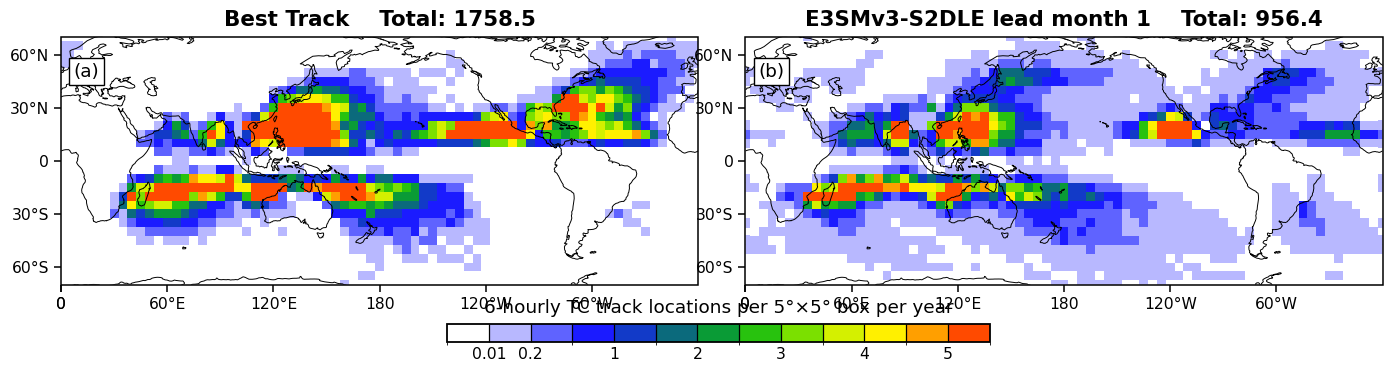

Annual-mean basin-integrated TC track-point density summary: 1980-2018, lead month 1


,lead,E3SM,BestTrack,E3SM/BestTrack
basin,,,,
NWP,1,181.256410,490.948718,0.369196
NA,1,53.256410,245.615385,0.216828
EP,1,114.112821,280.794872,0.406392
NI,1,75.220513,28.846154,2.607644
SI,1,276.617949,291.948718,0.947488
SP,1,102.171795,180.820513,0.565045


In [12]:
# ============================================================
# Compare annual global TC track density: Best Track vs E3SM
# ============================================================
#
# Definition:
#   TC track density = average number of 6-hourly TC track locations
#   within each DIAG_GRID_SIZE × DIAG_GRID_SIZE grid box per year.
#
# Annual global:
#   NH_JJASON + SH_DJFMAM, then averaged over years.
#
# For lead month 1:
#   May initialization      -> NH_JJASON
#   November initialization -> SH_DJFMAM
#
# Observations are masked to the same season-year pairs that have
# valid E3SM samples at the selected lead, so Best Track and E3SM
# are compared over the same target seasons.

import matplotlib.colors as mcolors

# ============================================================
# User-controlled setup parameters
# ============================================================

# Years
REQUESTED_YEARS = np.asarray(
    [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
    dtype=int,
)

# Seasons and lead
REQUIRED_SEASONS = ["NH_JJASON", "SH_DJFMAM"]
PLOT_LEAD = 1

# Plot labels
MODEL_LABEL = "E3SMv3-S2DLE"
OBS_LABEL = "Best Track"
DENSITY_LABEL = (
    f"6-hourly TC track locations per "
    f"{DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g}° box per year"
    if TRACK_DENSITY_METHOD == "box"
    else f"unique TC tracks within {TRACK_DENSITY_RADIUS_KM:g} km per year"
)

# Map/domain setup
MAP_EXTENT = [0, 360, -70, 70]
CENTRAL_LONGITUDE = 180
FIGSIZE = (14.0, 4.2)

# Axis ticks
XTICKS = np.arange(0, 361, 60)
XTICK_LABELS = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
YTICKS = [-60, -30, 0, 30, 60]
YTICK_LABELS = ["60°S", "30°S", "0", "30°N", "60°N"]

# Font-size setup
FONTZ = 14
TITLE_FONTSIZE = 1.10 * FONTZ
PANEL_LABEL_FONTSIZE = 0.95 * FONTZ
TICK_FONTSIZE = 0.80 * FONTZ
COLORBAR_TITLE_FONTSIZE = 0.95 * FONTZ
COLORBAR_TICK_FONTSIZE = 0.80 * FONTZ

# Colorbar setup
COLORBAR_BOUNDS = [
    0.0, 0.01, 0.2, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0
]

COLORBAR_TICKS = [0.01, 0.2, 1, 2, 3, 4, 5]
COLORBAR_TICK_LABELS = ["0.01", "0.2", "1", "2", "3", "4", "5"]

COLORBAR_COLORS = [
    "white",
    "#b8b8ff",
    "#5f63ff",
    "#1b1bff",
    "#123ac8",
    "#0b6a7c",
    "#0a9b36",
    "#28c20e",
    "#7be000",
    "#d4f000",
    "#fff000",
    "#ff9f00",
    "#ff4a00",
]

MIN_PLOT_VALUE = 0.01

# Styling
COASTLINE_WIDTH = 0.7
SPINE_WIDTH = 1.1
TICK_LENGTH = 5
TICK_WIDTH = 1.1
COLORBAR_OUTLINE_WIDTH = 1.3
COLORBAR_DIVIDER_WIDTH = 0.9

# ============================================================
# Year selection
# ============================================================

diag_years = DS_DIAG.year.astype(int).values
plot_years = np.intersect1d(REQUESTED_YEARS, diag_years)

if plot_years.size == 0:
    raise ValueError(
        f"No overlap between requested years {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]} "
        f"and DS_DIAG years {diag_years.min()}-{diag_years.max()}."
    )

if plot_years[0] != REQUESTED_YEARS[0] or plot_years[-1] != REQUESTED_YEARS[-1]:
    print(
        f"Requested {REQUESTED_YEARS[0]}-{REQUESTED_YEARS[-1]}, "
        f"but DS_DIAG covers {diag_years.min()}-{diag_years.max()}; "
        f"plotting {plot_years[0]}-{plot_years[-1]} ({plot_years.size} years)."
    )

# ============================================================
# Select model and observation count/sample arrays
# ============================================================

model_count = DS_DIAG["tc_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_count = DS_DIAG["obs_track_density_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_sample = DS_DIAG["sample_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_sample = DS_DIAG["obs_sample_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_storm_count = DS_DIAG["tc_storm_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_storm_count = DS_DIAG["obs_storm_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

# ============================================================
# Apply model-valid season/year mask before model-vs-observation comparison
# ============================================================

model_valid_season_year = model_sample > 0
valid_annual_year = model_valid_season_year.all("season")
valid_year_values = valid_annual_year.year.values[valid_annual_year.values]

if valid_year_values.size == 0:
    raise ValueError(
        f"No years have both {REQUIRED_SEASONS} sampled by E3SM at lead {PLOT_LEAD}."
    )

if valid_year_values.size != plot_years.size:
    dropped = sorted(set(plot_years.tolist()) - set(valid_year_values.tolist()))
    print(
        f"Lead {PLOT_LEAD}: dropping years without both model seasons sampled: {dropped}"
    )

plot_years = valid_year_values
model_count = model_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
obs_count = obs_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
model_sample = model_sample.sel(year=plot_years)
obs_sample = obs_sample.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
model_storm_count = model_storm_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))
obs_storm_count = obs_storm_count.sel(year=plot_years).where(model_valid_season_year.sel(year=plot_years))

# ============================================================
# Combine NH + SH into annual global TC-season count maps
# ============================================================

model_annual_count = model_count.sum("season", skipna=True, min_count=1)
obs_annual_count = obs_count.sum("season", skipna=True, min_count=1)

model_annual_storm_count = model_storm_count.sum("season", skipna=True, min_count=1)
obs_annual_storm_count = obs_storm_count.sum("season", skipna=True, min_count=1)

# NH_JJASON and SH_DJFMAM are two hemispheric pieces of the same
# annual global diagnostic, so the annual sample count should be
# the number of realizations, not the sum across seasons.
model_annual_sample = model_sample.where(model_valid_season_year.sel(year=plot_years)).min("season", skipna=True)
obs_annual_sample = obs_sample.min("season", skipna=True)

# Warn if seasonal sample counts differ.
model_sample_spread = (
    model_sample.max("season", skipna=True)
    - model_sample.min("season", skipna=True)
)
obs_sample_spread = (
    obs_sample.max("season", skipna=True)
    - obs_sample.min("season", skipna=True)
)

if float(model_sample_spread.max()) != 0:
    print(
        "Warning: model NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

if float(obs_sample_spread.max()) != 0:
    print(
        "Warning: obs NH and SH sample counts differ for at least one year. "
        "Using the smaller annual sample count."
    )

# ============================================================
# Normalize to annual density per realization/year
# ============================================================

model_annual_density = (
    model_annual_count / model_annual_sample.where(model_annual_sample > 0)
)

obs_annual_density = (
    obs_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
)

model_annual_storm_mean = (
    model_annual_storm_count / model_annual_sample.where(model_annual_sample > 0)
)

obs_annual_storm_mean = (
    obs_annual_storm_count / obs_annual_sample.where(obs_annual_sample > 0)
)

model_field = model_annual_density.mean("year", skipna=True)
obs_field = obs_annual_density.mean("year", skipna=True)

model_total = float(model_field.sum(("lat", "lon"), skipna=True))
obs_total = float(obs_field.sum(("lat", "lon"), skipna=True))

# ============================================================
# Diagnostics
# ============================================================

print(
    f"Lead {PLOT_LEAD} valid comparison years: "
    f"{int(plot_years[0])}-{int(plot_years[-1])} ({plot_years.size} years)."
)
print(
    f"Lead {PLOT_LEAD} annual sample count after model-valid masking: "
    f"E3SM mean={float(model_annual_sample.mean()):.1f}, "
    f"Best Track mean={float(obs_annual_sample.mean()):.1f}."
)

print(
    f"\nAnnual global detected storm counts (NH_JJASON + SH_DJFMAM):\n"
    f"  E3SM raw accumulated over samples: "
    f"{float(model_annual_storm_count.mean('year', skipna=True)):.1f}\n"
    f"  E3SM per-realization mean:        "
    f"{float(model_annual_storm_mean.mean('year', skipna=True)):.1f}\n"
    f"  Best Track observed mean:         "
    f"{float(obs_annual_storm_mean.mean('year', skipna=True)):.1f}"
)

print(
    f"\nAnnual global TC track-density map totals "
    f"summed over all {DIAG_GRID_SIZE:g}°×{DIAG_GRID_SIZE:g} grid points:\n"
    f"  E3SM raw accumulated over samples: "
    f"{float(model_annual_count.sum(('lat', 'lon'), skipna=True).mean('year')):.1f}\n"
    f"  E3SM per-realization mean:        {model_total:.1f}\n"
    f"  Best Track observed mean:         {obs_total:.1f}\n"
    f"  Note: this is not an annual storm count; one storm can contribute to multiple grid points."
)

print("\nModel annual sample count summary:")
display(model_annual_sample.to_series().describe())

print("\nObs annual sample count summary:")
display(obs_annual_sample.to_series().describe())

# ============================================================
# Colormap
# ============================================================

cmap = mcolors.ListedColormap(COLORBAR_COLORS)
cmap.set_bad((1, 1, 1, 0))
norm = mcolors.BoundaryNorm(COLORBAR_BOUNDS, cmap.N)

# ============================================================
# Plot formatting helper
# ============================================================

def _format_tc_density_axis(ax, title, panel_label):
    ax.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticks(XTICKS, crs=ccrs.PlateCarree())
    ax.set_xticklabels(XTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.set_yticks(YTICKS, crs=ccrs.PlateCarree())
    ax.set_yticklabels(YTICK_LABELS, fontsize=TICK_FONTSIZE)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH,
        top=False,
        right=False,
        labeltop=False,
        labelright=False,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

    ax.coastlines(linewidth=COASTLINE_WIDTH, color="black")

    ax.text(
        0.02,
        0.86,
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_FONTSIZE,
        ha="left",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "black",
            "boxstyle": "square,pad=0.25",
        },
        zorder=10,
    )

# ============================================================
# Plot Best Track vs E3SM
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGSIZE,
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=CENTRAL_LONGITUDE)},
)

plot_items = [
    (
        obs_field.where(obs_field >= MIN_PLOT_VALUE),
        f"{OBS_LABEL}    Total: {obs_total:.1f}",
        "(a)",
    ),
    (
        model_field.where(model_field >= MIN_PLOT_VALUE),
        f"{MODEL_LABEL} lead month {PLOT_LEAD}    Total: {model_total:.1f}",
        "(b)",
    ),
]

im = None
for ax, (field, title, panel_label) in zip(axes, plot_items):
    im = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
    )
    _format_tc_density_axis(ax, title, panel_label)

# Bottom boxed colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.12,
    shrink=0.50,
    aspect=30,
    fraction=0.060,
    boundaries=COLORBAR_BOUNDS,
    ticks=COLORBAR_TICKS,
    spacing="uniform",
    drawedges=True,
)

cbar.ax.set_title(DENSITY_LABEL, fontsize=COLORBAR_TITLE_FONTSIZE, pad=8)
cbar.ax.set_xticklabels(COLORBAR_TICK_LABELS, fontsize=COLORBAR_TICK_FONTSIZE)
cbar.ax.tick_params(length=0)

cbar.outline.set_linewidth(COLORBAR_OUTLINE_WIDTH)
if hasattr(cbar, "dividers"):
    cbar.dividers.set_color("black")
    cbar.dividers.set_linewidth(COLORBAR_DIVIDER_WIDTH)

fig.subplots_adjust(left=0.04, right=0.99, top=0.84, bottom=0.25, wspace=0.06)
plt.show()

# ============================================================
# Basin-integrated annual mean TC track density
# ============================================================

model_basin_count = DS_DIAG["tc_basin_track_density_count"].sel(
    lead=PLOT_LEAD,
    year=plot_years,
    season=REQUIRED_SEASONS,
)

obs_basin_count = DS_DIAG["obs_basin_track_density_count"].sel(
    year=plot_years,
    season=REQUIRED_SEASONS,
)

model_basin_count = model_basin_count.where(model_valid_season_year.sel(year=plot_years))
obs_basin_count = obs_basin_count.where(model_valid_season_year.sel(year=plot_years))

model_basin_annual_count = model_basin_count.sum("season", skipna=True, min_count=1)
obs_basin_annual_count = obs_basin_count.sum("season", skipna=True, min_count=1)

model_basin_annual_density = (
    model_basin_annual_count / model_annual_sample.where(model_annual_sample > 0)
)

obs_basin_annual_density = (
    obs_basin_annual_count / obs_annual_sample.where(obs_annual_sample > 0)
)

basin_summary = xr.Dataset(
    {
        "E3SM": model_basin_annual_density.mean("year", skipna=True),
        "BestTrack": obs_basin_annual_density.mean("year", skipna=True),
    }
).to_dataframe()

basin_summary = basin_summary[
    (basin_summary["E3SM"] != 0)
    | (basin_summary["BestTrack"] != 0)
].copy()

basin_summary["E3SM/BestTrack"] = (
    basin_summary["E3SM"] / basin_summary["BestTrack"]
)

print(
    f"Annual-mean basin-integrated TC track-point density summary: "
    f"{plot_years[0]}-{plot_years[-1]}, lead month {PLOT_LEAD}"
)

display(basin_summary)

## 9.  ENSO regression diagnostics

This block follows Yeager et al. Fig. 14: regress seasonal-mean TC track density on the corresponding seasonal-mean Niño-3.4 index, using JJASON in the Northern Hemisphere and DJFMAM in the Southern Hemisphere.  By default, the plot shows the full regression slope field and overlays 90% significant cells; set `PLOT_SIGNIFICANT_ONLY = True` only when you want a strict Yeager-caption mask.

The original Yeager et al. panel uses 1971-2018.  This notebook uses the configured diagnostic window (`years`-`yeare`; currently 1980-2018) unless you regenerate `DS_DIAG` for a longer period.  At 19-month lead, the final target season may be partial when the forecast files are only 24 months long: November starts contribute JJASO rather than JJASON, and May starts contribute DJFMA rather than DJFMAM.

For archives with only May/November starts, the available Yeager-style seasonal leads are `1, 7, 13, 19`; the plotting cell automatically drops leads with no model samples.

Set `NINO_FILE` to your Niño index NetCDF.  A monthly Niño-3.4 file is preferred so the code can average JJASON for `NH_JJASON` and DJFMAM for `SH_DJFMAM`; yearly input is accepted as a fallback.


In [13]:
# ---- Configure Niño index input ----
# Provide a monthly Niño-3.4 index file when possible. The regression uses
# Niño-3.4 averaged over the corresponding TC season:
#   NH_JJASON: June-November of year Y
#   SH_DJFMAM: December of year Y through May of year Y+1
# If the input is already yearly, the same yearly index is used for both seasons.
# Default generated by scripts/generate_nino34_enso_regression.py.
NINO_FILE = OUTDIR / "nino34_hadisst2_monthly_anom_clim1981_2010.nc"
NINO_VAR = "nino34"
REG_NINO_LABEL = "hadisst2"

from scipy.stats import t as student_t

SIG_CONFIDENCE = 0.90
SIG_ALPHA = 1.0 - SIG_CONFIDENCE



def _guess_nino_var(ds: xr.Dataset) -> str:
    """Pick a likely Niño variable if NINO_VAR is not set."""
    preferred = ["nino34_ann", "nino34", "nino", "nino34_index", "oni"]
    for name in preferred:
        if name in ds.data_vars:
            return name
    one_dim = [name for name, da in ds.data_vars.items() if da.ndim == 1]
    if len(one_dim) == 1:
        return one_dim[0]
    raise ValueError(
        "Could not infer Niño variable. Set NINO_VAR to one of: "
        + ", ".join(ds.data_vars)
    )


def load_seasonal_nino_index(path: Path, varname: str | None = None) -> xr.DataArray:
    """Load Niño index as DataArray(season, year), averaged over TC seasons."""
    ds = xr.open_dataset(path)
    varname = varname or _guess_nino_var(ds)
    da = ds[varname]

    if "time" not in da.dims and "year" not in da.dims:
        dim = da.dims[0]
        coord = da[dim].values if dim in da.coords else np.arange(da.sizes[dim])
        if np.issubdtype(np.asarray(coord).dtype, np.datetime64):
            da = da.rename({dim: "time"}).assign_coords(time=coord)
        else:
            da = da.assign_coords(year=(dim, coord.astype(int))).swap_dims({dim: "year"}).drop_vars(dim, errors="ignore")

    extra_dims = [d for d in da.dims if d not in ("time", "year")]
    if extra_dims:
        da = da.mean(extra_dims)

    if "time" in da.dims:
        time = pd.to_datetime(da["time"].values)
        month = time.month
        year = time.year
        nh_mask = np.isin(month, [6, 7, 8, 9, 10, 11])

        nh = (
            da.isel(time=nh_mask)
            .assign_coords(year=("time", year[nh_mask]))
            .groupby("year")
            .mean("time")
        )

        sh_mask = np.isin(month, [12, 1, 2, 3, 4, 5])
        sh_year = np.where(month == 12, year, year - 1)
        sh = (
            da.isel(time=sh_mask)
            .assign_coords(year=("time", sh_year[sh_mask]))
            .groupby("year")
            .mean("time")
        )

        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([nh, sh], dim=season_coord)
    elif "year" in da.dims:
        yearly = da.rename({"year": "year"})
        season_coord = xr.DataArray(season_names, dims="season", name="season")
        nino = xr.concat([yearly, yearly], dim=season_coord)
        print("Niño input is yearly; using the same yearly index for both TC seasons.")

    nino = nino.astype(float).sortby("year").transpose("season", "year")
    nino.name = "seasonal_nino34_index"
    nino.attrs.update({"source_file": str(path), "source_variable": varname})
    return nino


def regression_tcrit(n: xr.DataArray, confidence: float = SIG_CONFIDENCE) -> xr.DataArray:
    """Two-sided Student-t threshold for correlation/slope significance."""
    alpha = 1.0 - confidence
    return xr.apply_ufunc(
        lambda n_: student_t.ppf(1.0 - alpha / 2.0, np.maximum(n_ - 2, 1)),
        n.astype(float),
        vectorize=True,
        dask="allowed",
    ).where(n >= 3)


def xr_regress_y_on_x(y: xr.DataArray, x: xr.DataArray, sample_dim: str = "year") -> xr.Dataset:
    """
    Regress y against x along sample_dim.

    Returns slope, intercept, correlation, t-value for correlation/slope, and n.
    The t-value is r * sqrt((n - 2) / (1 - r**2)).
    """
    x, y = xr.align(x, y, join="inner")
    valid = np.isfinite(x) & np.isfinite(y)

    n = valid.sum(sample_dim)
    x_valid = x.where(valid)
    y_valid = y.where(valid)

    x_mean = x_valid.mean(sample_dim, skipna=True)
    y_mean = y_valid.mean(sample_dim, skipna=True)
    x_anom = x_valid - x_mean
    y_anom = y_valid - y_mean

    cov_xy = (x_anom * y_anom).sum(sample_dim, skipna=True)
    var_x = (x_anom ** 2).sum(sample_dim, skipna=True)
    var_y = (y_anom ** 2).sum(sample_dim, skipna=True)

    slope = (cov_xy / var_x).where(n >= 3)
    intercept = (y_mean - slope * x_mean).where(n >= 3)
    corr = cov_xy / np.sqrt(var_x * var_y)
    corr = corr.where(n >= 3)

    tval = corr * np.sqrt((n - 2) / (1 - corr ** 2))
    tval = tval.where(n >= 3)

    return xr.Dataset({
        "slope": slope,
        "intercept": intercept,
        "corr": corr,
        "tval": tval,
        "n": n,
    })


if NINO_FILE is None:
    print("Set NINO_FILE to your Niño-3.4 index NetCDF, then rerun this cell.")
else:
    if "DS_DIAG" not in globals():
        DIAG_OUT = OUTDIR / f"tc_lead_track_density_{case_prefix}_{PARSET}_{years}_{yeare}.nc"
        if not DIAG_OUT.exists():
            raise FileNotFoundError(f"Run the track-density diagnostic first; missing {DIAG_OUT}")
        DS_DIAG = xr.open_dataset(DIAG_OUT)
        print(f"Loaded existing track-density diagnostics: {DIAG_OUT}")

    nino_index = load_seasonal_nino_index(Path(NINO_FILE), NINO_VAR)
    for required_var in ["tc_track_density_mean", "obs_track_density_mean"]:
        if required_var not in DS_DIAG:
            raise ValueError(
                f"DS_DIAG is missing {required_var!r}. Run the IBTrACS observed "
                "track-density companion block before regression."
            )

    analysis_years = np.asarray(
        [y for y in range(years, yeare + 1) if yexcl is None or y != yexcl],
        dtype=int,
    )
    diag_years = DS_DIAG.year.astype(int).values
    nino_years = nino_index.year.astype(int).values
    common_years = np.intersect1d(np.intersect1d(analysis_years, diag_years), nino_years)
    outside_analysis_years = np.setdiff1d(diag_years, analysis_years)
    missing_diag_years = np.setdiff1d(analysis_years, diag_years)
    missing_nino_years = np.setdiff1d(analysis_years, nino_years)

    if common_years.size < 3:
        raise ValueError(
            f"Need at least 3 overlapping years for regression; found {common_years.size}. "
            f"analysis years={analysis_years.min()}-{analysis_years.max()}, "
            f"DS_DIAG years={diag_years.min()}-{diag_years.max()}, "
            f"Niño years={nino_years.min()}-{nino_years.max()}"
        )
    print(f"Regression analysis years: {common_years.min()}-{common_years.max()} ({common_years.size} years)")
    if outside_analysis_years.size:
        print(f"Ignoring DS_DIAG years outside configured model window: {outside_analysis_years.tolist()}")
    if missing_diag_years.size:
        print(f"Configured model years missing from DS_DIAG: {missing_diag_years.tolist()}")
    if missing_nino_years.size:
        print(f"Configured model years missing from Niño index: {missing_nino_years.tolist()}")

    DS_DIAG_REG = DS_DIAG.sel(year=common_years)
    nino_index = nino_index.sel(year=common_years)
    print(nino_index)

    model_density_for_regression = DS_DIAG_REG["tc_track_density_mean"]
    if "sample_count" in DS_DIAG_REG:
        model_density_for_regression = model_density_for_regression.where(DS_DIAG_REG["sample_count"] > 0)
        empty_samples = (DS_DIAG_REG["sample_count"].sum("year") == 0)
        if bool(empty_samples.any()):
            empty_labels = [
                f"{str(season)} lead {int(lead)}"
                for season in empty_samples.season.values
                for lead in empty_samples.lead.values
                if bool(empty_samples.sel(season=season, lead=lead))
            ]
            print("No model samples for: " + ", ".join(empty_labels))

    reg_model = xr_regress_y_on_x(model_density_for_regression, nino_index)
    reg_obs = xr_regress_y_on_x(DS_DIAG_REG["obs_track_density_mean"], nino_index)

    model_tcrit = regression_tcrit(reg_model["n"])
    obs_tcrit = regression_tcrit(reg_obs["n"])

    # Rename variables to clear model/obs names in one output dataset.
    DS_REG = xr.Dataset({
        "model_slope": reg_model["slope"],
        "model_intercept": reg_model["intercept"],
        "model_corr": reg_model["corr"],
        "model_tval": reg_model["tval"],
        "model_n": reg_model["n"],
        "model_sample_count": DS_DIAG_REG["sample_count"] if "sample_count" in DS_DIAG_REG else reg_model["n"],
        "obs_slope": reg_obs["slope"],
        "obs_intercept": reg_obs["intercept"],
        "obs_corr": reg_obs["corr"],
        "obs_tval": reg_obs["tval"],
        "obs_n": reg_obs["n"],
        "model_tcrit_90": model_tcrit,
        "obs_tcrit_90": obs_tcrit,
        "model_slope_sig": reg_model["slope"].where(np.abs(reg_model["tval"]) >= model_tcrit, 0.0),
        "obs_slope_sig": reg_obs["slope"].where(np.abs(reg_obs["tval"]) >= obs_tcrit, 0.0),
        "nino_index": nino_index,
    })


    DS_REG.attrs.update({
        "description": "Regression of TC-season track-density diagnostics against Niño-3.4 averaged over the corresponding TC season.",
        "nino_file": str(NINO_FILE),
        "nino_variable": nino_index.attrs.get("source_variable", "unknown"),
        "significance_confidence_level": SIG_CONFIDENCE,
        "significance_test": "two-sided Student-t test using n - 2 degrees of freedom",
        "sample_mask": "Model regression masks tc_track_density_mean where sample_count <= 0.",
        "density_file": str(DIAG_OUT),
    })

    REG_OUT = OUTDIR / f"tc_lead_track_density_enso_regression_{case_prefix}_{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
    write_netcdf(DS_REG, REG_OUT)
    print(f"Saved regression diagnostics: {REG_OUT}")
    print(DS_REG)


Regression analysis years: 1980-2018 (39 years)
<xarray.DataArray 'seasonal_nino34_index' (season: 2, year: 39)> Size: 624B
array([[-0.08056809, -0.35642096,  1.21362606, -0.4101526 , -0.5727859 ,
        -0.55701581,  0.43863109,  1.35016456, -1.53030166, -0.40813179,
         0.17914178,  0.79227678,  0.09038933,  0.23505355,  0.62820927,
        -0.56082804, -0.32523694,  1.95953179, -1.07598089, -1.17124642,
        -0.58361934, -0.0949588 ,  1.0795052 ,  0.27014144,  0.65050986,
        -0.08993137,  0.48830146, -0.86598209, -0.28495322,  0.78664567,
        -1.274582  , -0.67851972,  0.33303954, -0.21871529,  0.31739784,
         2.02345322, -0.4505316 , -0.18231881,  0.50192209],
       [-0.39540519,  0.14986223,  1.66312017, -0.56336783, -0.98112486,
        -0.4572927 ,  0.9645167 ,  0.15351291, -1.36779036,  0.11203534,
         0.32699834,  1.54262998,  0.42516897,  0.22294693,  0.65597818,
        -0.6216701 , -0.12707631,  1.61750851, -1.25869294, -1.23587305,
        -0.5

Plotting model leads with available seasonal samples: [1, 7, 13, 19]
Saved Yeager-style regression plot: /global/homes/z/zhan391/code/ESP-Lab/jupyter/tc_lead_track_density_enso_regression_yeager_style_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_set3_1980_2018_hadisst2.png


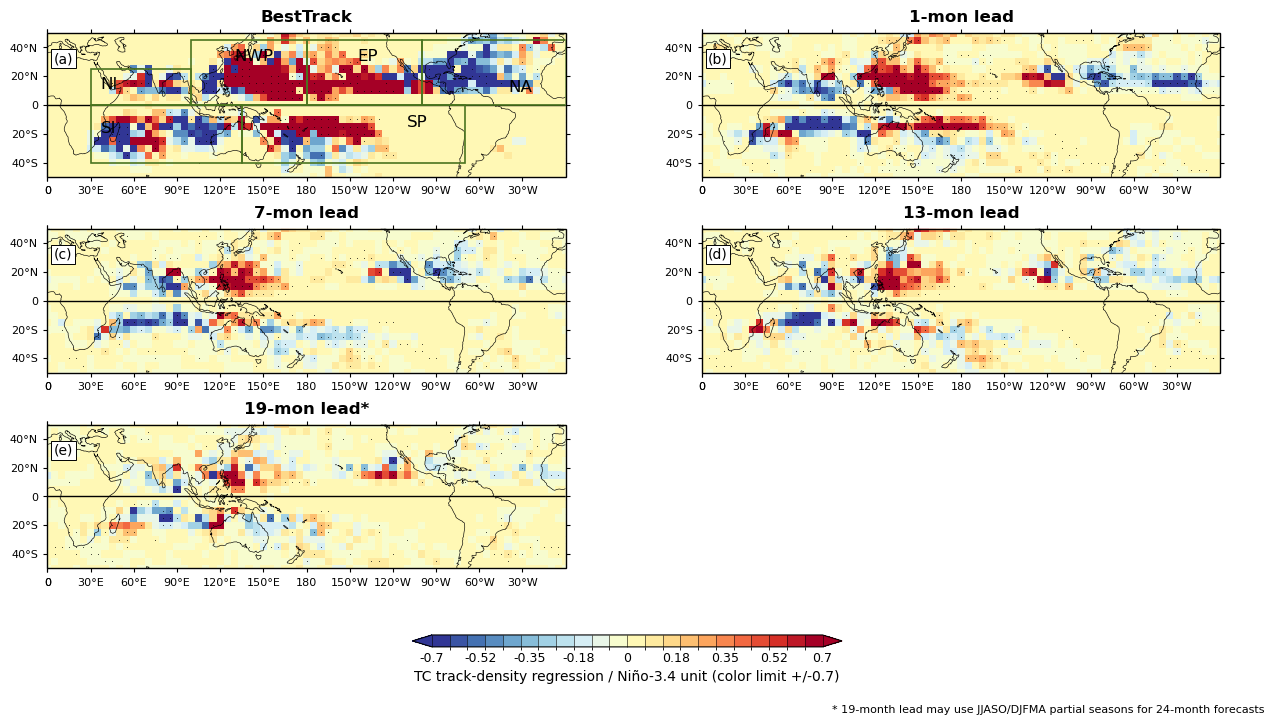

In [14]:
# Yeager-style Fig. 14 regression panel: BestTrack plus E3SM lead months.
# Default: plot the full regression slope field so weak model responses remain visible,
# and overlay small black markers where cells pass the 90% two-sided significance test.
# Set PLOT_SIGNIFICANT_ONLY=True to reproduce a strict significant-shading-only view.
# At 19-month lead, available 24-month forecasts may represent JJASO/DJFMA partial target seasons.
import matplotlib.colors as mcolors

REG_OUT = OUTDIR / f"tc_lead_track_density_enso_regression_{case_prefix}_{PARSET}_{years}_{yeare}_{REG_NINO_LABEL}.nc"
if "DS_REG" not in globals():
    if REG_OUT.exists():
        DS_REG = xr.open_dataset(REG_OUT)
        print(f"Loaded existing regression diagnostics: {REG_OUT}")
    else:
        matches = sorted(OUTDIR.glob(f"tc_lead_track_density_enso_regression_{case_prefix}_*_{years}_{yeare}_{REG_NINO_LABEL}.nc"))
        if len(matches) == 1:
            REG_OUT = matches[0]
            DS_REG = xr.open_dataset(REG_OUT)
            print(f"Loaded existing regression diagnostics with matching case/year/Niño label: {REG_OUT}")
        elif matches:
            raise FileNotFoundError(
                f"Missing configured regression file {REG_OUT}. Matching alternatives exist: "
                + ", ".join(str(p) for p in matches)
            )
        else:
            raise FileNotFoundError(f"Run the regression cell first; missing {REG_OUT}")

FIGDIR = NOTEBOOK_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)
PLOT_SIGNIFICANT_ONLY = False
PLOT_SIGNIFICANCE_MARKERS = True
PLOT_MARKER_STRIDE = 1
if "model_sample_count" in DS_REG:
    sample_by_lead = DS_REG["model_sample_count"].sum(("season", "year"), skipna=True)
    PLOT_LEADS = [int(lead) for lead in DS_REG.lead.values if float(sample_by_lead.sel(lead=lead)) > 0]
else:
    PLOT_LEADS = [int(lead) for lead in LEADS]
if not PLOT_LEADS:
    raise ValueError("No model leads with positive sample count are available for plotting.")
print(f"Plotting model leads with available seasonal samples: {PLOT_LEADS}")

# Global TC-season map: NH_JJASON for Northern Hemisphere basins and
# SH_DJFMAM for Southern Hemisphere basins, matching the NCL Fig. 14 layout.
obs_map = DS_REG["obs_slope"].sum("season", skipna=True, min_count=1)
model_maps = [DS_REG["model_slope"].sel(lead=lead).sum("season", skipna=True, min_count=1) for lead in PLOT_LEADS]
obs_sig = DS_REG["obs_slope_sig"].sum("season", skipna=True, min_count=1) != 0
model_sigs = [DS_REG["model_slope_sig"].sel(lead=lead).sum("season", skipna=True, min_count=1) != 0 for lead in PLOT_LEADS]

if PLOT_SIGNIFICANT_ONLY:
    obs_map = obs_map.where(obs_sig)
    model_maps = [field.where(sig) for field, sig in zip(model_maps, model_sigs)]
    PLOT_SIGNIFICANCE_MARKERS = False

COLOR_LIMIT_MODE = "model_auto"  # "model_auto" reveals weak E3SM slopes; use "yeager" for +/-2.2.
COLOR_LIMIT = 2.2
COLOR_LIMIT_MIN = 0.2
COLOR_LIMIT_PERCENTILE = 99.0
if COLOR_LIMIT_MODE == "yeager":
    color_limit = float(COLOR_LIMIT)
else:
    model_values = np.concatenate([
        np.ravel(np.asarray(field.values, dtype=float))
        for field in model_maps
        if np.isfinite(field.values).any()
    ])
    model_values = np.abs(model_values[np.isfinite(model_values)])
    if model_values.size:
        color_limit = max(COLOR_LIMIT_MIN, float(np.nanpercentile(model_values, COLOR_LIMIT_PERCENTILE)))
        color_limit = np.ceil(color_limit * 10.0) / 10.0
    else:
        color_limit = float(COLOR_LIMIT)
YEAGER_LEVELS = np.arange(-color_limit, color_limit + color_limit / 11.0, color_limit / 11.0)
YEAGER_TICKS = np.linspace(-color_limit, color_limit, 9)
cmap = plt.get_cmap("RdYlBu_r").copy()
cmap.set_bad((1, 1, 1, 0))

YEAGER_BASINS = {
    "NI":  {"lon1": 30,  "lon2": 100, "lat1": 0,   "lat2": 25, "text_xy": (37, 14)},
    "NWP": {"lon1": 100, "lon2": 180, "lat1": 0,   "lat2": 45, "text_xy": (130, 34)},
    "EP":  {"lon1": 180, "lon2": 260, "lat1": 0,   "lat2": 45, "text_xy": (215, 34)},
    "NA":  {"lon1": 260, "lon2": 360, "lat1": 0,   "lat2": 45, "text_xy": (320, 12)},
    "SI":  {"lon1": 30,  "lon2": 135, "lat1": -40, "lat2": 0,  "text_xy": (37, -16)},
    "SP":  {"lon1": 135, "lon2": 290, "lat1": -40, "lat2": 0,  "text_xy": (250, -12)},
}

def _lon_label(x):
    x = int(x) % 360
    if x == 0:
        return "0"
    if x == 180:
        return "180"
    return f"{x}°E" if x < 180 else f"{360 - x}°W"

def _lat_label(y):
    y = int(y)
    if y == 0:
        return "0"
    return f"{abs(y)}°N" if y > 0 else f"{abs(y)}°S"

def _coord_edges(coord):
    coord = np.asarray(coord, dtype=float)
    mids = 0.5 * (coord[:-1] + coord[1:])
    first = coord[0] - 0.5 * (coord[1] - coord[0])
    last = coord[-1] + 0.5 * (coord[-1] - coord[-2])
    return np.concatenate([[first], mids, [last]])

def _field_for_pcolormesh(field):
    field = field.transpose("lat", "lon")
    lon = field["lon"].values
    lat = field["lat"].values
    return field.values, _coord_edges(lon), _coord_edges(lat)

def _plot_sig_markers(ax, sig):
    if not PLOT_SIGNIFICANCE_MARKERS:
        return
    sig = sig.transpose("lat", "lon")
    sig_values = sig.values.astype(bool)
    if PLOT_MARKER_STRIDE > 1:
        keep = np.zeros_like(sig_values, dtype=bool)
        keep[::PLOT_MARKER_STRIDE, ::PLOT_MARKER_STRIDE] = True
        sig_values &= keep
    yy, xx = np.where(sig_values)
    if yy.size == 0:
        return
    ax.scatter(
        sig["lon"].values[xx], sig["lat"].values[yy],
        s=1.8, marker=".", color="black", alpha=0.65,
        linewidths=0, transform=ccrs.PlateCarree(), zorder=5,
    )

def _plot_regression_panel(ax, field, sig, title, panel_label, show_basin_boxes=False):
    data, lon_edges, lat_edges = _field_for_pcolormesh(field)
    has_data = np.isfinite(data).any()
    im = ax.pcolormesh(
        lon_edges, lat_edges, data,
        cmap=cmap,
        norm=mcolors.BoundaryNorm(YEAGER_LEVELS, cmap.N),
        transform=ccrs.PlateCarree(),
        shading="flat",
    )
    _plot_sig_markers(ax, sig)
    if not has_data:
        ax.text(
            0.5, 0.5, "no samples", transform=ax.transAxes,
            ha="center", va="center", fontsize=12, color="0.25",
            bbox={"facecolor": "white", "edgecolor": "0.5", "boxstyle": "square,pad=0.25", "alpha": 0.85},
            zorder=8,
        )
    ax.set_extent([0, 360, -50, 50], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.45, color="black")
    ax.plot([0, 360], [0, 0], color="black", linewidth=1.0, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)

    xticks = np.arange(0, 361, 30)
    yticks = [-40, -20, 0, 20, 40]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels([_lon_label(x) for x in xticks], fontsize=8)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.set_yticklabels([_lat_label(y) for y in yticks], fontsize=8)
    ax.tick_params(axis="both", which="major", direction="out", length=3.2, width=0.8,
                   top=True, right=True, labeltop=False, labelright=False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    ax.text(
        0.012, 0.82, panel_label, transform=ax.transAxes,
        fontsize=10, ha="left", va="center",
        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "square,pad=0.18", "linewidth": 0.7},
    )

    if show_basin_boxes:
        import matplotlib.patches as mpatches
        for name, b in YEAGER_BASINS.items():
            rect = mpatches.Rectangle(
                (b["lon1"], b["lat1"]),
                b["lon2"] - b["lon1"],
                b["lat2"] - b["lat1"],
                fill=False,
                linewidth=1.2,
                edgecolor="#4b751f",
                transform=ccrs.PlateCarree(),
                zorder=6,
            )
            ax.add_patch(rect)
            ax.text(
                b["text_xy"][0], b["text_xy"][1], name,
                transform=ccrs.PlateCarree(),
                fontsize=12, ha="left", va="center", color="black", zorder=7,
            )
    return im

n_panels = 1 + len(PLOT_LEADS)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(13.2, 2.55 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
axes = np.atleast_1d(axes).ravel()
panel_labels = [f"({chr(97 + i)})" for i in range(n_panels)]
titles = ["BestTrack"] + [f"{lead}-mon lead" + ("*" if lead == 19 else "") for lead in PLOT_LEADS]
fields = [obs_map] + model_maps
sigs = [obs_sig] + model_sigs

im = None
for idx, (ax, field, sig, title, panel_label) in enumerate(zip(axes[:n_panels], fields, sigs, titles, panel_labels)):
    im = _plot_regression_panel(
        ax, field, sig, title, panel_label,
        show_basin_boxes=(idx == 0),
    )
for ax in axes[n_panels:]:
    ax.remove()

cbar = fig.colorbar(
    im, ax=axes[:n_panels], orientation="horizontal", pad=0.070, shrink=0.42,
    aspect=36, fraction=0.030, ticks=YEAGER_TICKS, extend="both", drawedges=True,
)
cbar.ax.set_xticklabels([f"{tick:.2g}" for tick in YEAGER_TICKS])
cbar.ax.tick_params(labelsize=9, length=0)
cbar.set_label(f"TC track-density regression / Niño-3.4 unit (color limit +/-{color_limit:g})", fontsize=10)
if 19 in PLOT_LEADS:
    fig.text(
        0.995, 0.035,
        "* 19-month lead may use JJASO/DJFMA partial seasons for 24-month forecasts",
        ha="right", va="center", fontsize=8,
    )

fig.subplots_adjust(left=0.04, right=0.995, top=0.92, bottom=0.22, hspace=0.36, wspace=0.08)
_reg_token = REG_OUT.name.replace("tc_lead_track_density_enso_regression_", "")
FIG_REG_OUT = FIGDIR / f"tc_lead_track_density_enso_regression_yeager_style_{_reg_token.replace('.nc', '.png')}"
fig.savefig(FIG_REG_OUT, dpi=200, bbox_inches="tight")
print(f"Saved Yeager-style regression plot: {FIG_REG_OUT}")
plt.show()
